# Fine Tuning with Optuna Framework

In [1]:
!pip install optuna --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 18.5 MB/s eta 0:00:00


In [2]:
!pip install optuna-integration[sklearn]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.5/98.5 kB 5.5 MB/s eta 0:00:00


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import optuna

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.base import clone

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier


from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler, ClusterCentroids
from imblearn.combine import SMOTETomek, SMOTEENN
from scipy.stats import loguniform

import warnings
import os
import json

pd.set_option('display.max_columns', None)
warnings.filterwarnings("ignore", category=FutureWarning)

In [25]:
# Configurar conexion con google drive y con carpeta de google colab
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/Colab Notebooks/Prediccion de Adiciones Proyectos de Infraestructura')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# Load list of columns
with open('Data/projectsColumns.txt', 'r') as f:
    projectsColumns = f.read().splitlines()
with open('Data/contractColumns.txt', 'r') as f:
    contractColumns = f.read().splitlines()
with open('Data/buyerColumns.txt', 'r') as f:
    buyerColumns = f.read().splitlines()
with open('Data/supplierColumns.txt', 'r') as f:
    supplierColumns = f.read().splitlines()
with open('Data/buyerIndicatorsColumns.txt', 'r') as f:
    buyerIndicators = f.read().splitlines()
with open('Data/terridataColumns.txt', 'r') as f:
    terridataColumns = f.read().splitlines()
with open('Data/outcomeColumns.txt', 'r') as f:
    outcomeColumns = f.read().splitlines()

In [6]:
df = pd.read_csv('Data/trainData.csv')   # Load the data
df = df[df['contractValueMw(G1)'] > 1e3].copy().reset_index()  # Filter out rows with contractValueMw(G1) <= 1000
# convert contractMonthSigned(G2) and contractMonthStart(G2) to object
df['contractMonthSigned(G2)'] = df['contractMonthSigned(G2)'].astype(str)
df['contractMonthStart(G2)'] = df['contractMonthStart(G2)'].astype(str)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6994 entries, 0 to 6993
Data columns (total 52 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   index                                  6994 non-null   int64  
 1   contractValueMw(G1)                    6994 non-null   float64
 2   contractDurationDays(G1)               6994 non-null   float64
 3   projectIntensityMw(G1)                 6994 non-null   float64
 4   workCategory(G1)                       6994 non-null   object 
 5   tenderValueMw(G2)                      6994 non-null   float64
 6   bidContractRatio(G2)                   6994 non-null   float64
 7   contractMethodType(G2)                 6994 non-null   object 
 8   contractMonthSigned(G2)                6994 non-null   object 
 9   contractMonthStart(G2)                 6994 non-null   object 
 10  electoralYear(G2)                      6994 non-null   int64  
 11  pree

In [26]:
def optuna_fine_tune_classification_model(
    X_train,
    y_train,
    model,
    param_suggest_dict,
    X_test=None,
    y_test=None,
    n_trials=50,
    cv=5,
    scoring='roc_auc',
    direction='maximize',
    timeout=None,
    resampling_strategy=None,
    resampling_ratio=None,
    numeric_features=None,
    categorical_features=None,
    random_state=42,
    n_jobs=-1
):
    """
    Realiza optimización de hiperparámetros para un modelo de clasificación utilizando Optuna,
    con manejo de características categóricas y numéricas, y múltiples opciones de balanceo.

    Parámetros:
    -----------
    X_train : DataFrame
        Datos de entrenamiento con características.
    y_train : Series
        Variable objetivo.
    model : estimator
        Modelo de clasificación de scikit-learn.
    param_suggest_dict : dict
        Diccionario con funciones de sugerencia para Optuna.
        Ejemplo: {
            'max_depth': lambda trial: trial.suggest_int('max_depth', 3, 10),
            'learning_rate': lambda trial: trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
        }
    X_test : DataFrame, default=None
        Datos de prueba con características. Si es None, se utilizará X_train.
    y_test : Series, default=None
        Variable objetivo para los datos de prueba. Si es None, se utilizará y_train.
    n_trials : int, default=50
        Número de pruebas para Optuna.
    cv : int, default=5
        Número de folds para validación cruzada.
    scoring : str, default='roc_auc'
        Métrica para evaluar el rendimiento del modelo.
    direction : str, default='maximize'
        Dirección de optimización: 'maximize' o 'minimize'.
    timeout : int, default=None
        Tiempo límite para la optimización (en segundos).
    resampling_strategy : str, default=None
        Estrategia de resampling:
        - Oversampling: 'smote', 'adasyn', 'random_over'
        - Undersampling: 'random_under', 'cluster_centroids'
        - Combinadas: 'smotetomek', 'smoteenn'
        - None: sin resampling
    resampling_ratio : float, default=None
        Proporción de clases deseada después del resampling.
    numeric_features : list, default=None
        Lista de nombres de características numéricas.
    categorical_features : list, default=None
        Lista de nombres de características categóricas.
    random_state : int, default=42
        Semilla para reproducibilidad.
    n_jobs : int, default=-1
        Número de trabajos paralelos.

    Retorna:
    --------
    dict
        Diccionario con los siguientes elementos:
        - 'best_estimator': Mejor estimador encontrado.
        - 'best_params': Mejores parámetros encontrados.
        - 'best_score': Mejor puntaje obtenido.
        - 'metrics': Diccionario con métricas del mejor modelo.
        - 'study': Objeto estudio de Optuna.
        - 'importance': Importancia de los parámetros.
        - 'results_df': DataFrame con todos los resultados de las pruebas.
    """


    # Si no se especifican las características, inferirlas
    if numeric_features is None and categorical_features is None:
        numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
        categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

    # Crear transformadores para cada tipo de característica
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    # Preprocesamiento de características
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ]
    )

    # Configurar el resampling según la estrategia seleccionada
    resampler = None
    if resampling_strategy:
        if resampling_ratio is None:
            resampling_ratio = 'auto'

        # Estrategias de oversampling
        if resampling_strategy == 'smote':
            resampler = SMOTE(sampling_strategy=resampling_ratio, random_state=random_state)
        elif resampling_strategy == 'adasyn':
            resampler = ADASYN(sampling_strategy=resampling_ratio, random_state=random_state)
        elif resampling_strategy == 'random_over':
            resampler = RandomOverSampler(sampling_strategy=resampling_ratio, random_state=random_state)

        # Estrategias de undersampling
        elif resampling_strategy == 'random_under':
            resampler = RandomUnderSampler(sampling_strategy=resampling_ratio, random_state=random_state)
        elif resampling_strategy == 'cluster_centroids':
            resampler = ClusterCentroids(sampling_strategy=resampling_ratio, random_state=random_state)

        # Estrategias combinadas
        elif resampling_strategy == 'smotetomek':
            resampler = SMOTETomek(sampling_strategy=resampling_ratio, random_state=random_state)
        elif resampling_strategy == 'smoteenn':
            resampler = SMOTEENN(sampling_strategy=resampling_ratio, random_state=random_state)

    # Crear base pipeline para ser clonada en cada trial
    if resampler:
        base_pipeline = ImbPipeline([
            ('preprocessor', preprocessor),
            ('resampler', resampler),
            ('classifier', model)
        ])
    else:
        base_pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', model)
        ])

    # Manejar X_test e y_test cuando son None
    if X_test is None:
        X_test = X_train
    if y_test is None:
        y_test = y_train

    # Configurar validación cruzada estratificada
    stratified_cv = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)

    # Definir función objetivo para Optuna
    def objective(trial):
        # Clonar el modelo base para este trial
        from sklearn.base import clone
        pipeline = clone(base_pipeline)

        # Aplicar las funciones de sugerencia de parámetros
        params = {}
        for param_name, suggest_func in param_suggest_dict.items():
            params[param_name] = suggest_func(trial)

        # Configurar el modelo con los parámetros sugeridos
        for param_name, param_value in params.items():
            setattr(pipeline.named_steps['classifier'], param_name, param_value)

        # Evaluar el modelo con validación cruzada
        try:
            scores = cross_val_score(
                pipeline,
                X_train,
                y_train,
                scoring=scoring,
                cv=stratified_cv,
                n_jobs=n_jobs
            )
            return np.mean(scores)
        except Exception as e:
            # Manejar errores y asignar un valor punitivo
            print(f"Error en trial {trial.number}: {str(e)}")
            return float('-inf') if direction == 'maximize' else float('inf')

    # Crear el estudio de Optuna
    study = optuna.create_study(
        direction=direction,
        sampler=optuna.samplers.TPESampler(seed=random_state)
    )

    # Ejecutar la optimización
    study.optimize(
        objective,
        n_trials=n_trials,
        timeout=timeout,
        n_jobs=1,  # Ya usamos paralelismo en cross_val_score
        show_progress_bar=True
    )

    # Obtener los mejores parámetros
    best_params = study.best_params
    best_score = study.best_value

    # Aplicar los mejores parámetros al modelo
    best_pipeline = clone(base_pipeline)
    for param_name, param_value in best_params.items():
        setattr(best_pipeline.named_steps['classifier'], param_name, param_value)

    # Entrenar el modelo con los mejores parámetros
    best_pipeline.fit(X_train, y_train)

    # Hacer predicciones
    y_pred = best_pipeline.predict(X_test)
    try:
        y_prob = best_pipeline.predict_proba(X_test)[:, 1]
    except (AttributeError, IndexError):
        # Si el modelo no tiene predict_proba o solo tiene una clase
        y_prob = None

    # Calcular métricas
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
    }

    # Añadir ROC AUC si es posible
    if y_prob is not None:
        metrics['roc_auc'] = roc_auc_score(y_test, y_prob)

    # Obtener importancia de parámetros
    try:
        importance = optuna.importance.get_param_importances(study)
    except:
        importance = {}
        print("No se pudo calcular la importancia de los parámetros")

    # Crear DataFrame con los resultados de las pruebas
    results_df = study.trials_dataframe()

    return {
        'best_estimator': best_pipeline,
        'best_params': best_params,
        'best_score': best_score,
        'metrics': metrics,
        'study': study,
        'importance': importance,
        'results_df': results_df
    }

In [30]:
def print_results(results):
  # Mostrar los resultados
  print(f"Mejor puntuación (ROC AUC): {results['best_score']:.4f}")
  print("\nMejores parámetros encontrados:")
  for param, value in results['best_params'].items():
      print(f"- {param}: {value}")

  print("\nMétricas en el conjunto de prueba:")
  for metric, value in results['metrics'].items():
      print(f"- {metric}: {value:.4f}")

  print("\nImportancia de los parámetros:")
  for param, importance in results['importance'].items():
      print(f"- {param}: {importance:.4f}")

  # Gráfico de historia de optimización
  plt.figure(figsize=(10, 6))
  optuna.visualization.matplotlib.plot_optimization_history(results['study'])
  plt.title("Historia de optimización")
  plt.tight_layout()
  plt.show()

In [35]:
def save_results(results, filename, folder):
    dir_path = os.path.join(folder, filename)
    with open(dir_path, "w") as archivo:
      json.dump(results['best_params'], archivo)

## Escenario 1

In [9]:
# Separate features and target
X1 = df[projectsColumns + contractColumns]
y1 = df['haveCostDeviation(G7)']

# %%
# select categorical columns
categoricalColumns = X1.select_dtypes(include=['object']).columns
# select numerical columns
numericColumns = X1.select_dtypes(include=['int64', 'float64']).columns

# %%
# Split data into training and testing sets
X_train_s1, X_test_s1, y_train_s1, y_test_s1 = train_test_split(X1, y1, test_size=0.3, random_state=42, stratify=y1)

### Logistic Regression

In [31]:
# Definir el modelo base
lr_model_s1 = LogisticRegression(max_iter=10000, solver='liblinear', random_state=42)

# Definir grid de busqueda
param_suggest_dict_lr = {
    'penalty': lambda trial: trial.suggest_categorical('penalty', ['l1', 'l2']),
    'C': lambda trial: trial.suggest_loguniform('C', 1e-4, 1e4),
}

# Usar la función para optimizar el modelo
lr_s1_optuna_results = optuna_fine_tune_classification_model(
    X_train=X_train_s1,
    y_train=y_train_s1,
    model=lr_model_s1,
    param_suggest_dict=param_suggest_dict_lr,
    X_test=X_test_s1,
    y_test=y_test_s1,
    n_trials=30,  # Reducido para el ejemplo
    cv=3,          # Reducido para el ejemplo
    scoring='roc_auc',
    direction='maximize',
    timeout=None,
    resampling_strategy='smoteenn',  # Ejemplo con SMOTE
    random_state=42
)

[I 2025-04-28 14:55:57,003] A new study created in memory with name: no-name-77e760d6-2fa0-4459-ac6e-290e88700cad


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-04-28 14:56:06,165] Trial 0 finished with value: 0.5659489615874117 and parameters: {'penalty': 'l2', 'C': 71.77141927992021}. Best is trial 0 with value: 0.5659489615874117.
[I 2025-04-28 14:56:09,965] Trial 1 finished with value: 0.5 and parameters: {'penalty': 'l1', 'C': 0.0017699302940633358}. Best is trial 0 with value: 0.5659489615874117.
[I 2025-04-28 14:56:15,975] Trial 2 finished with value: 0.5657719053515327 and parameters: {'penalty': 'l2', 'C': 6.4405075539937195}. Best is trial 0 with value: 0.5659489615874117.
[I 2025-04-28 14:56:26,291] Trial 3 finished with value: 0.565505449369559 and parameters: {'penalty': 'l1', 'C': 5744.851636320435}. Best is trial 0 with value: 0.5659489615874117.
[I 2025-04-28 14:56:31,839] Trial 4 finished with value: 0.5 and parameters: {'penalty': 'l1', 'C': 0.002848391870910803}. Best is trial 0 with value: 0.5659489615874117.
[I 2025-04-28 14:56:34,739] Trial 5 finished with value: 0.5653858639733227 and parameters: {'penalty': 'l2'

Mejor puntuación (ROC AUC): 0.5661

Mejores parámetros encontrados:
- penalty: l2
- C: 30.48153720784848

Métricas en el conjunto de prueba:
- accuracy: 0.4545
- precision: 0.3579
- recall: 0.7431
- f1: 0.4831
- roc_auc: 0.5520

Importancia de los parámetros:
- C: 0.9047
- penalty: 0.0953


<ipython-input-30-6e4859f440e2>:18: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(results['study'])


<Figure size 1000x600 with 0 Axes>

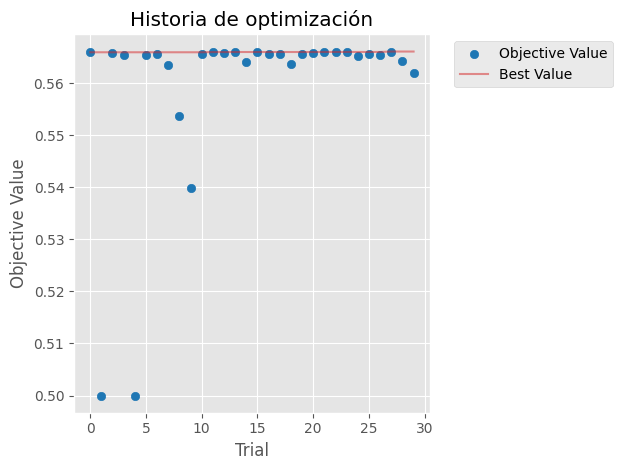

In [32]:
print_results(lr_s1_optuna_results)

In [36]:
save_results(lr_s1_optuna_results, 'lr_s1_optuna_best_params.json', 'Parameters')

In [29]:
with open("Parameters/lr_s1_optuna_best_params.json", "r") as archivo:
    lr_s1_optuna_best_params = json.load(archivo)
print(lr_s1_optuna_best_params)

{'penalty': 'l2', 'C': 30.48153720784848}


### Random Forest

In [37]:
param_suggest_dict_rf = {
    # Profundidad máxima: ampliando el rango para explorar más posibilidades
    'max_depth': lambda trial: trial.suggest_int('max_depth', 5, 50),

    # Número de estimadores: mantener el rango original pero con exploración continua
    'n_estimators': lambda trial: trial.suggest_int('n_estimators', 50, 500),

    # Samples para dividir: explorar valores con distribución logarítmica
    'min_samples_split': lambda trial: trial.suggest_int('min_samples_split', 2, 20),

    # Samples en hojas: explorar valores con distribución logarítmica
    'min_samples_leaf': lambda trial: trial.suggest_int('min_samples_leaf', 1, 10),

    # Características a considerar: explorar valores continuos y categóricos
    'max_features': lambda trial: trial.suggest_categorical('max_features', ['sqrt', 'log2'])
                    if trial.suggest_categorical('max_features_type', ['auto', 'float']) == 'auto'
                    else trial.suggest_float('max_features_float', 0.1, 0.9),

    # Parámetros adicionales que podrían mejorar el rendimiento
    'bootstrap': lambda trial: trial.suggest_categorical('bootstrap', [True, False]),
}


rf_model_s1 = RandomForestClassifier(random_state=42)

# Usar la función para optimizar el modelo
rf_s1_optuna_results = optuna_fine_tune_classification_model(
    X_train=X_train_s1,
    y_train=y_train_s1,
    model=rf_model_s1,
    param_suggest_dict=param_suggest_dict_rf,
    X_test=X_test_s1,
    y_test=y_test_s1,
    n_trials=30,  # Reducido para el ejemplo
    cv=3,          # Reducido para el ejemplo
    scoring='roc_auc',
    direction='maximize',
    timeout=None,
    resampling_strategy='smoteenn',  # Ejemplo con SMOTE
    random_state=42
)

[I 2025-04-28 15:07:50,479] A new study created in memory with name: no-name-b90d380a-2377-4c16-a89c-37b9ca301066


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-04-28 15:08:06,632] Trial 0 finished with value: 0.5809125790832447 and parameters: {'max_depth': 22, 'n_estimators': 478, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features_type': 'auto', 'max_features': 'log2', 'bootstrap': False}. Best is trial 0 with value: 0.5809125790832447.
[I 2025-04-28 15:08:21,441] Trial 1 finished with value: 0.583154718596514 and parameters: {'max_depth': 5, 'n_estimators': 487, 'min_samples_split': 17, 'min_samples_leaf': 3, 'max_features_type': 'float', 'max_features_float': 0.3433937943676302, 'bootstrap': True}. Best is trial 1 with value: 0.583154718596514.
[I 2025-04-28 15:09:02,911] Trial 2 finished with value: 0.5679966003820026 and parameters: {'max_depth': 18, 'n_estimators': 325, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features_type': 'float', 'max_features_float': 0.728140769114411, 'bootstrap': False}. Best is trial 1 with value: 0.583154718596514.
[I 2025-04-28 15:09:11,921] Trial 3 finished with value: 0.5770792

Mejor puntuación (ROC AUC): 0.5848

Mejores parámetros encontrados:
- max_depth: 9
- n_estimators: 358
- min_samples_split: 10
- min_samples_leaf: 2
- max_features_type: auto
- max_features: sqrt
- bootstrap: True

Métricas en el conjunto de prueba:
- accuracy: 0.4936
- precision: 0.3788
- recall: 0.7444
- f1: 0.5021
- roc_auc: 0.6039

Importancia de los parámetros:
- max_features_type: 0.4104
- bootstrap: 0.2924
- min_samples_leaf: 0.1055
- n_estimators: 0.0848
- min_samples_split: 0.0739
- max_depth: 0.0330


<ipython-input-30-6e4859f440e2>:18: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(results['study'])


<Figure size 1000x600 with 0 Axes>

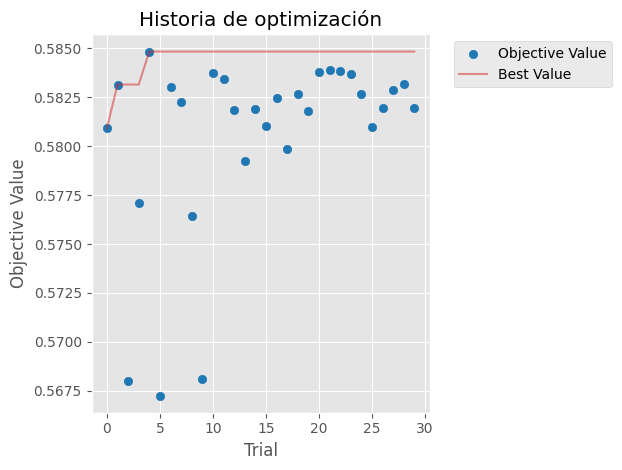

In [38]:
print_results(rf_s1_optuna_results)
save_results(rf_s1_optuna_results, 'rf_s1_optuna_best_params.json', 'Parameters')

### Extreme Gradient Boosting

In [39]:
# Definir el modelo base
xgb_model_s1 = XGBClassifier(random_state=42)

# Definir el diccionario de sugerencias de parámetros para Optuna
param_suggest_dict_xgb = {
    'max_depth': lambda trial: trial.suggest_int('max_depth', 3, 10),
    'learning_rate': lambda trial: trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
    'n_estimators': lambda trial: trial.suggest_int('n_estimators', 50, 300),
    'min_child_weight': lambda trial: trial.suggest_int('min_child_weight', 1, 10),
    'subsample': lambda trial: trial.suggest_float('subsample', 0.5, 1.0),
    'colsample_bytree': lambda trial: trial.suggest_float('colsample_bytree', 0.5, 1.0),
    'gamma': lambda trial: trial.suggest_float('gamma', 0, 5)
}

# Usar la función para optimizar el modelo
xgb_s1_optuna_results = optuna_fine_tune_classification_model(
    X_train=X_train_s1,
    y_train=y_train_s1,
    model=xgb_model_s1,
    param_suggest_dict=param_suggest_dict_xgb,
    X_test=X_test_s1,
    y_test=y_test_s1,
    n_trials=30,
    cv=3,
    scoring='roc_auc',
    direction='maximize',
    timeout=None,
    resampling_strategy='smoteenn',
    random_state=42
)

[I 2025-04-28 15:14:12,611] A new study created in memory with name: no-name-695735ff-37ca-4e8b-9311-eb495c28ed47


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-04-28 15:14:16,099] Trial 0 finished with value: 0.5656888111274067 and parameters: {'max_depth': 5, 'learning_rate': 0.2536999076681772, 'n_estimators': 233, 'min_child_weight': 6, 'subsample': 0.5780093202212182, 'colsample_bytree': 0.5779972601681014, 'gamma': 0.2904180608409973}. Best is trial 0 with value: 0.5656888111274067.
[I 2025-04-28 15:14:19,626] Trial 1 finished with value: 0.5813848902926588 and parameters: {'max_depth': 9, 'learning_rate': 0.07725378389307355, 'n_estimators': 227, 'min_child_weight': 1, 'subsample': 0.9849549260809971, 'colsample_bytree': 0.9162213204002109, 'gamma': 1.0616955533913808}. Best is trial 1 with value: 0.5813848902926588.
[I 2025-04-28 15:14:23,012] Trial 2 finished with value: 0.5821770949947743 and parameters: {'max_depth': 4, 'learning_rate': 0.018659959624904916, 'n_estimators': 126, 'min_child_weight': 6, 'subsample': 0.7159725093210578, 'colsample_bytree': 0.645614570099021, 'gamma': 3.0592644736118975}. Best is trial 2 with va

Mejor puntuación (ROC AUC): 0.5853

Mejores parámetros encontrados:
- max_depth: 7
- learning_rate: 0.019180053856939716
- n_estimators: 152
- min_child_weight: 2
- subsample: 0.6037974415545304
- colsample_bytree: 0.9507351757623951
- gamma: 4.447782097330527

Métricas en el conjunto de prueba:
- accuracy: 0.5460
- precision: 0.4000
- recall: 0.6472
- f1: 0.4944
- roc_auc: 0.5950

Importancia de los parámetros:
- gamma: 0.6246
- learning_rate: 0.2037
- colsample_bytree: 0.0654
- max_depth: 0.0410
- subsample: 0.0375
- n_estimators: 0.0170
- min_child_weight: 0.0108


<ipython-input-30-6e4859f440e2>:18: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(results['study'])


<Figure size 1000x600 with 0 Axes>

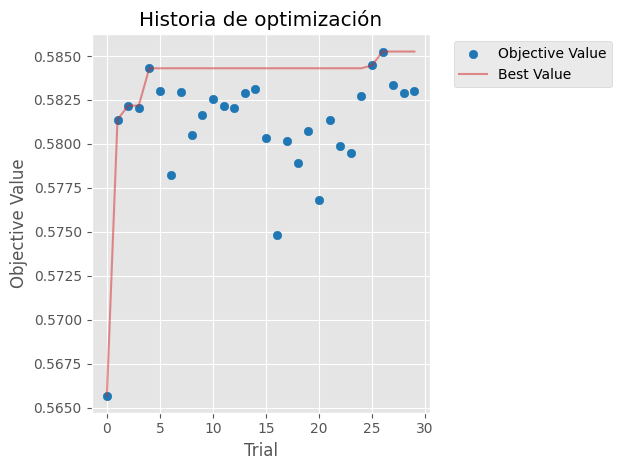

In [40]:
print_results(xgb_s1_optuna_results)
save_results(xgb_s1_optuna_results, 'xgb_s1_optuna_best_params.json', 'Parameters')

### K Nearest Neighbors

In [41]:
param_suggest_dict_knn = {
    # Número de vecinos: explorar un rango más amplio y continuo
    'n_neighbors': lambda trial: trial.suggest_int('n_neighbors', 1, 30),

    # Función de pesos
    'weights': lambda trial: trial.suggest_categorical('weights', ['uniform', 'distance']),

    # Métrica de distancia con manejo condicional para el parámetro p
    'metric': lambda trial: trial.suggest_categorical('metric', ['euclidean', 'manhattan', 'minkowski', 'chebyshev']),

    # Parámetro p solo relevante cuando metric='minkowski'
    'p': lambda trial: trial.suggest_int('p', 1, 5) if trial.params.get('metric') == 'minkowski' else 2,

    # Algoritmo para calcular vecinos
    'algorithm': lambda trial: trial.suggest_categorical('algorithm', ['auto', 'ball_tree', 'kd_tree', 'brute']),

    # Tamaño de hoja - importante para ball_tree y kd_tree
    'leaf_size': lambda trial: trial.suggest_int('leaf_size', 10, 100)
                 if trial.params.get('algorithm') in ['ball_tree', 'kd_tree'] else 30
}
knn_model_s1 = KNeighborsClassifier()

knn_s1_optuna_results = optuna_fine_tune_classification_model(
    X_train=X_train_s1,
    y_train=y_train_s1,
    model=knn_model_s1,
    param_suggest_dict=param_suggest_dict_knn,
    X_test=X_test_s1,
    y_test=y_test_s1,
    n_trials=30,
    cv=3,
    scoring='roc_auc',
    direction='maximize',
    timeout=None,
    resampling_strategy='smoteenn',
    random_state=42
)

[I 2025-04-28 15:16:49,328] A new study created in memory with name: no-name-1ac7447a-f6d8-43ac-99a8-5aeb6d427313


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-04-28 15:16:53,770] Trial 0 finished with value: 0.5477173384689763 and parameters: {'n_neighbors': 12, 'weights': 'uniform', 'metric': 'euclidean', 'algorithm': 'auto'}. Best is trial 0 with value: 0.5477173384689763.
Error en trial 1: 
All the 3 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/imblearn/pipe

/usr/local/lib/python3.11/dist-packages/sklearn/neighbors/_base.py:598: UserWarning: cannot use tree with sparse input: using brute force
  warnings.warn("cannot use tree with sparse input: using brute force")


Mejor puntuación (ROC AUC): 0.5625

Mejores parámetros encontrados:
- n_neighbors: 27
- weights: distance
- metric: manhattan
- algorithm: kd_tree
- leaf_size: 69

Métricas en el conjunto de prueba:
- accuracy: 0.6327
- precision: 0.4518
- recall: 0.3319
- f1: 0.3827
- roc_auc: 0.5841

Importancia de los parámetros:
- metric: 0.4778
- algorithm: 0.2735
- n_neighbors: 0.2273
- weights: 0.0214


<ipython-input-30-6e4859f440e2>:18: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(results['study'])


<Figure size 1000x600 with 0 Axes>

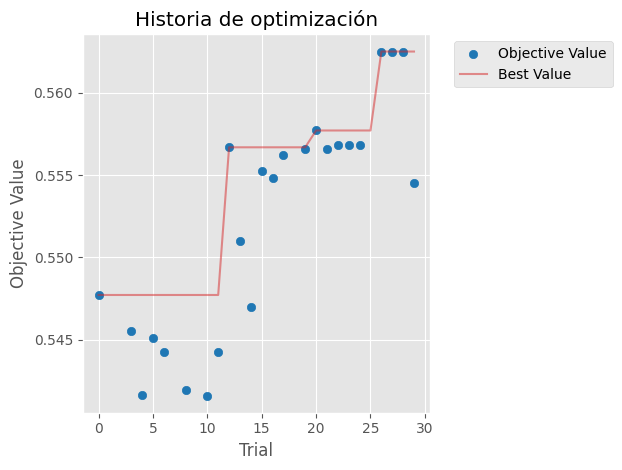

In [42]:
print_results(knn_s1_optuna_results)
save_results(knn_s1_optuna_results, 'knn_s1_optuna_best_params.json', 'Parameters')

## Escenario 2

In [43]:
# Separate features and target
X2 = df[projectsColumns + contractColumns + buyerColumns + supplierColumns]
y2 = df['haveCostDeviation(G7)']

# %%
# select categorical columns
categoricalColumns = X2.select_dtypes(include=['object']).columns
# select numerical columns
numericColumns = X2.select_dtypes(include=['int64', 'float64']).columns

# %%
# Split data into training and testing sets
X_train_s2, X_test_s2, y_train_s2, y_test_s2 = train_test_split(X2, y2, test_size=0.3, random_state=42, stratify=y2)

### Logistic Regression

In [44]:
lr_model_s2 = LogisticRegression(max_iter=10000, solver='liblinear', random_state=42)
# Usar la función para optimizar el modelo
lr_s2_optuna_results = optuna_fine_tune_classification_model(
    X_train=X_train_s2,
    y_train=y_train_s2,
    model=lr_model_s2,
    param_suggest_dict=param_suggest_dict_lr,
    X_test=X_test_s2,
    y_test=y_test_s2,
    n_trials=30,  # Reducido para el ejemplo
    cv=3,          # Reducido para el ejemplo
    scoring='roc_auc',
    direction='maximize',
    timeout=None,
    resampling_strategy='smoteenn',  # Ejemplo con SMOTE
    random_state=42
)

[I 2025-04-28 15:19:45,957] A new study created in memory with name: no-name-65c62021-1ef8-4e8a-bd96-4e37198cf34f


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-04-28 15:19:52,343] Trial 0 finished with value: 0.6734311030936552 and parameters: {'penalty': 'l2', 'C': 71.77141927992021}. Best is trial 0 with value: 0.6734311030936552.
[I 2025-04-28 15:19:57,708] Trial 1 finished with value: 0.5 and parameters: {'penalty': 'l1', 'C': 0.0017699302940633358}. Best is trial 0 with value: 0.6734311030936552.
[I 2025-04-28 15:20:03,470] Trial 2 finished with value: 0.6774630165442274 and parameters: {'penalty': 'l2', 'C': 6.4405075539937195}. Best is trial 2 with value: 0.6774630165442274.
[I 2025-04-28 15:20:16,192] Trial 3 finished with value: 0.6703025232100424 and parameters: {'penalty': 'l1', 'C': 5744.851636320435}. Best is trial 2 with value: 0.6774630165442274.
[I 2025-04-28 15:20:22,953] Trial 4 finished with value: 0.6110168077323579 and parameters: {'penalty': 'l1', 'C': 0.002848391870910803}. Best is trial 2 with value: 0.6774630165442274.
[I 2025-04-28 15:20:28,188] Trial 5 finished with value: 0.6789284405105193 and parameters: 

Mejor puntuación (ROC AUC): 0.6791

Mejores parámetros encontrados:
- penalty: l2
- C: 0.8511359491169641

Métricas en el conjunto de prueba:
- accuracy: 0.5460
- precision: 0.4149
- recall: 0.7889
- f1: 0.5438
- roc_auc: 0.6506

Importancia de los parámetros:
- C: 0.9046
- penalty: 0.0954


<ipython-input-30-6e4859f440e2>:18: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(results['study'])


<Figure size 1000x600 with 0 Axes>

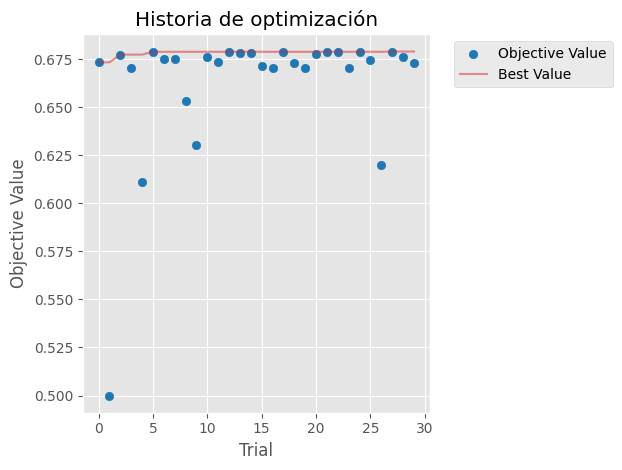

In [45]:
print_results(lr_s2_optuna_results)
save_results(lr_s2_optuna_results, 'lr_s2_optuna_best_params.json', 'Parameters')

### Random Forest

In [48]:
rf_model_s2 = RandomForestClassifier(random_state=42)
rf_s2_optuna_results = optuna_fine_tune_classification_model(
    X_train=X_train_s2,
    y_train=y_train_s2,
    model=rf_model_s2,
    param_suggest_dict=param_suggest_dict_rf,
    X_test=X_test_s2,
    y_test=y_test_s2,
    n_trials=30,
    cv=3,
    scoring='roc_auc',
    direction='maximize',
    timeout=None,
    resampling_strategy='smoteenn',
    random_state=42
)

[I 2025-04-28 15:37:36,318] A new study created in memory with name: no-name-f1a332f2-bf8a-4a2c-b052-7497b3fc7faf


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-04-28 15:37:52,242] Trial 0 finished with value: 0.6800518673880789 and parameters: {'max_depth': 22, 'n_estimators': 478, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features_type': 'auto', 'max_features': 'log2', 'bootstrap': False}. Best is trial 0 with value: 0.6800518673880789.
[I 2025-04-28 15:38:03,211] Trial 1 finished with value: 0.6696355429161693 and parameters: {'max_depth': 5, 'n_estimators': 487, 'min_samples_split': 17, 'min_samples_leaf': 3, 'max_features_type': 'float', 'max_features_float': 0.3433937943676302, 'bootstrap': True}. Best is trial 0 with value: 0.6800518673880789.
[I 2025-04-28 15:38:36,654] Trial 2 finished with value: 0.6576580872232881 and parameters: {'max_depth': 18, 'n_estimators': 325, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features_type': 'float', 'max_features_float': 0.728140769114411, 'bootstrap': False}. Best is trial 0 with value: 0.6800518673880789.
[I 2025-04-28 15:38:45,441] Trial 3 finished with value: 0.6670

Mejor puntuación (ROC AUC): 0.6829

Mejores parámetros encontrados:
- max_depth: 26
- n_estimators: 222
- min_samples_split: 5
- min_samples_leaf: 3
- max_features_type: auto
- max_features: log2
- bootstrap: False

Métricas en el conjunto de prueba:
- accuracy: 0.5874
- precision: 0.4412
- recall: 0.7611
- f1: 0.5586
- roc_auc: 0.6768

Importancia de los parámetros:
- max_features_type: 0.7330
- bootstrap: 0.1174
- min_samples_split: 0.0486
- min_samples_leaf: 0.0421
- max_depth: 0.0404
- n_estimators: 0.0185


<ipython-input-30-6e4859f440e2>:18: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(results['study'])


<Figure size 1000x600 with 0 Axes>

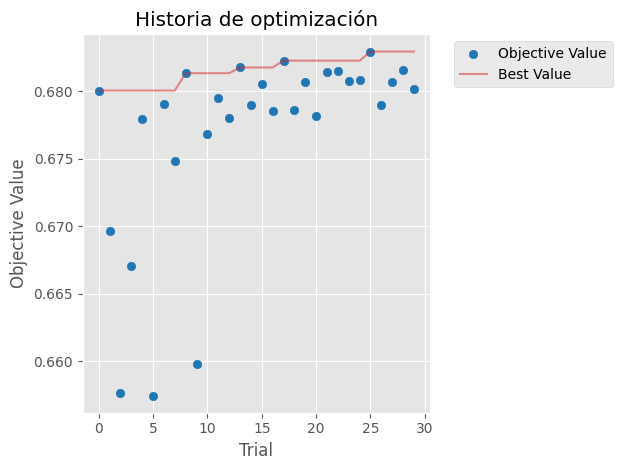

In [49]:
print_results(rf_s2_optuna_results)
save_results(rf_s2_optuna_results, 'rf_s2_optuna_best_params.json', 'Parameters')

### Extreme Gradient Boosting

In [51]:
xgb_model_s2 = XGBClassifier(random_state=42)
xgb_s2_optuna_results = optuna_fine_tune_classification_model(
    X_train=X_train_s2,
    y_train=y_train_s2,
    model=xgb_model_s2,
    param_suggest_dict=param_suggest_dict_xgb,
    X_test=X_test_s2,
    y_test=y_test_s2,
    n_trials=30,
    cv=3,
    scoring='roc_auc',
    direction='maximize',
    timeout=None,
    resampling_strategy='smoteenn',
    random_state=42
)

[I 2025-04-28 15:53:46,539] A new study created in memory with name: no-name-2422bd67-579f-4372-a25a-53d90edc1866


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-04-28 15:53:59,533] Trial 0 finished with value: 0.6615794017390685 and parameters: {'max_depth': 5, 'learning_rate': 0.2536999076681772, 'n_estimators': 233, 'min_child_weight': 6, 'subsample': 0.5780093202212182, 'colsample_bytree': 0.5779972601681014, 'gamma': 0.2904180608409973}. Best is trial 0 with value: 0.6615794017390685.
[I 2025-04-28 15:54:10,925] Trial 1 finished with value: 0.6774830143263685 and parameters: {'max_depth': 9, 'learning_rate': 0.07725378389307355, 'n_estimators': 227, 'min_child_weight': 1, 'subsample': 0.9849549260809971, 'colsample_bytree': 0.9162213204002109, 'gamma': 1.0616955533913808}. Best is trial 1 with value: 0.6774830143263685.
[I 2025-04-28 15:54:17,761] Trial 2 finished with value: 0.6663604967233535 and parameters: {'max_depth': 4, 'learning_rate': 0.018659959624904916, 'n_estimators': 126, 'min_child_weight': 6, 'subsample': 0.7159725093210578, 'colsample_bytree': 0.645614570099021, 'gamma': 3.0592644736118975}. Best is trial 1 with va

Mejor puntuación (ROC AUC): 0.6820

Mejores parámetros encontrados:
- max_depth: 6
- learning_rate: 0.04640945380224746
- n_estimators: 226
- min_child_weight: 1
- subsample: 0.8933139358849991
- colsample_bytree: 0.8109750979300321
- gamma: 0.7588193356487098

Métricas en el conjunto de prueba:
- accuracy: 0.6122
- precision: 0.4566
- recall: 0.6861
- f1: 0.5483
- roc_auc: 0.6688

Importancia de los parámetros:
- min_child_weight: 0.3370
- subsample: 0.2390
- n_estimators: 0.1652
- gamma: 0.1222
- colsample_bytree: 0.0980
- max_depth: 0.0214
- learning_rate: 0.0172


<ipython-input-30-6e4859f440e2>:18: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(results['study'])


<Figure size 1000x600 with 0 Axes>

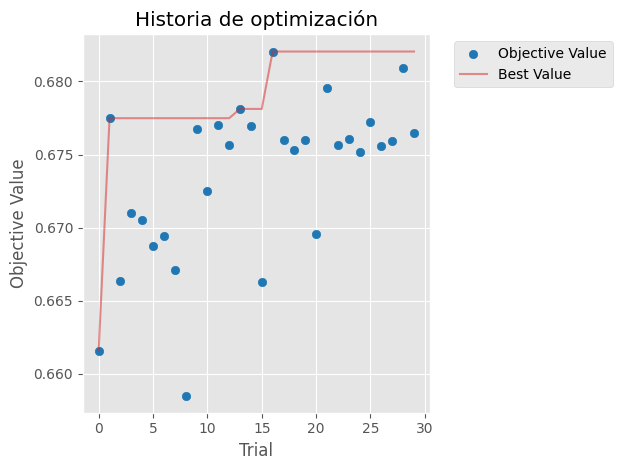

In [52]:
print_results(xgb_s2_optuna_results)
save_results(xgb_s2_optuna_results, 'xgb_s2_optuna_best_params.json', 'Parameters')

### K Nearest Neighbors

In [53]:
knn_model_s2 = KNeighborsClassifier()
knn_s2_optuna_results = optuna_fine_tune_classification_model(
    X_train=X_train_s2,
    y_train=y_train_s2,
    model=knn_model_s2,
    param_suggest_dict=param_suggest_dict_knn,
    X_test=X_test_s2,
    y_test=y_test_s2,
    n_trials=30,
    cv=3,
    scoring='roc_auc',
    direction='maximize',
    timeout=None,
    resampling_strategy='smoteenn',
    random_state=42
)

[I 2025-04-28 15:58:14,935] A new study created in memory with name: no-name-b1a0a11c-e315-476c-aa29-2c2ae57258a6


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-04-28 15:58:19,845] Trial 0 finished with value: 0.6341360954141889 and parameters: {'n_neighbors': 12, 'weights': 'uniform', 'metric': 'euclidean', 'algorithm': 'auto'}. Best is trial 0 with value: 0.6341360954141889.
Error en trial 1: 
All the 3 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/imblearn/pipe

Mejor puntuación (ROC AUC): 0.6737

Mejores parámetros encontrados:
- n_neighbors: 20
- weights: distance
- metric: manhattan
- algorithm: brute

Métricas en el conjunto de prueba:
- accuracy: 0.6117
- precision: 0.4503
- recall: 0.5972
- f1: 0.5134
- roc_auc: 0.6630

Importancia de los parámetros:
- metric: 0.6554
- n_neighbors: 0.2172
- weights: 0.0978
- algorithm: 0.0296


<ipython-input-30-6e4859f440e2>:18: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(results['study'])


<Figure size 1000x600 with 0 Axes>

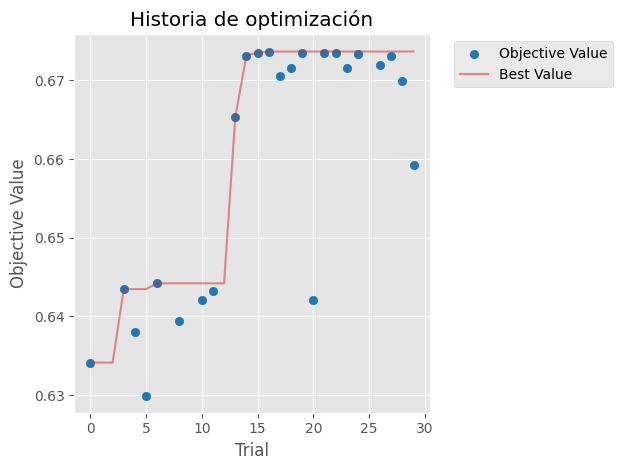

In [54]:
print_results(knn_s2_optuna_results)
save_results(knn_s2_optuna_results, 'knn_s2_optuna_best_params.json', 'Parameters')

## Escenario 3

In [55]:
# Separate features and target
X3 = df[projectsColumns + contractColumns + buyerColumns + supplierColumns + buyerIndicators]
y3 = df['haveCostDeviation(G7)']

# %%
# select categorical columns
categoricalColumns = X3.select_dtypes(include=['object']).columns
# select numerical columns
numericColumns = X3.select_dtypes(include=['int64', 'float64']).columns

# %%
# Split data into training and testing sets
X_train_s3, X_test_s3, y_train_s3, y_test_s3 = train_test_split(X3, y3, test_size=0.3, random_state=42, stratify=y3)

### Logistic Regression

In [56]:
lr_model_s3 = LogisticRegression(max_iter=10000, solver='liblinear', random_state=42)
lr_s3_optuna_results = optuna_fine_tune_classification_model(
    X_train=X_train_s3,
    y_train=y_train_s3,
    model=lr_model_s3,
    param_suggest_dict=param_suggest_dict_lr,
    X_test=X_test_s3,
    y_test=y_test_s3,
    n_trials=30,
    cv=3,
    scoring='roc_auc',
    direction='maximize',
    timeout=None,
    resampling_strategy='smoteenn',
    random_state=42
)

[I 2025-04-28 16:00:38,191] A new study created in memory with name: no-name-8d178faa-ca18-469d-9576-fe8785565d33


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-04-28 16:00:44,520] Trial 0 finished with value: 0.6920908282428263 and parameters: {'penalty': 'l2', 'C': 71.77141927992021}. Best is trial 0 with value: 0.6920908282428263.
[I 2025-04-28 16:00:51,323] Trial 1 finished with value: 0.5 and parameters: {'penalty': 'l1', 'C': 0.0017699302940633358}. Best is trial 0 with value: 0.6920908282428263.
[I 2025-04-28 16:00:56,982] Trial 2 finished with value: 0.6969372774591774 and parameters: {'penalty': 'l2', 'C': 6.4405075539937195}. Best is trial 2 with value: 0.6969372774591774.
[I 2025-04-28 16:01:08,307] Trial 3 finished with value: 0.6882361130712398 and parameters: {'penalty': 'l1', 'C': 5744.851636320435}. Best is trial 2 with value: 0.6969372774591774.
[I 2025-04-28 16:01:14,288] Trial 4 finished with value: 0.6617002118846097 and parameters: {'penalty': 'l1', 'C': 0.002848391870910803}. Best is trial 2 with value: 0.6969372774591774.
[I 2025-04-28 16:01:21,208] Trial 5 finished with value: 0.7001796298980437 and parameters: 

Mejor puntuación (ROC AUC): 0.7035

Mejores parámetros encontrados:
- penalty: l2
- C: 0.17728308166268825

Métricas en el conjunto de prueba:
- accuracy: 0.5588
- precision: 0.4270
- recall: 0.8361
- f1: 0.5653
- roc_auc: 0.6876

Importancia de los parámetros:
- C: 0.7107
- penalty: 0.2893


<ipython-input-30-6e4859f440e2>:18: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(results['study'])


<Figure size 1000x600 with 0 Axes>

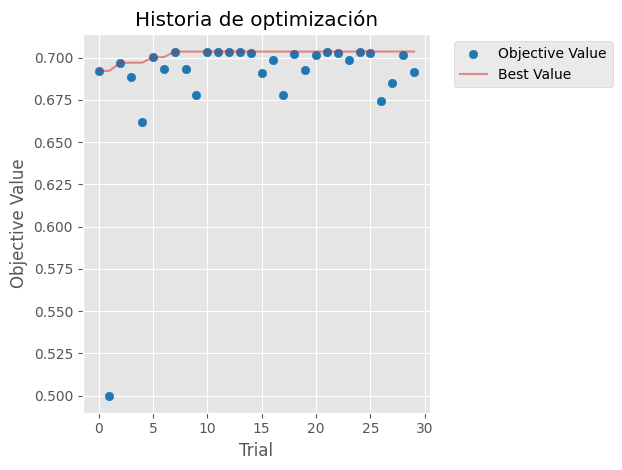

In [57]:
print_results(lr_s3_optuna_results)
save_results(lr_s3_optuna_results, 'lr_s3_optuna_best_params.json', 'Parameters')

### Random Forest

In [58]:
rf_model_s3 = RandomForestClassifier(random_state=42)
rf_s3_optuna_results = optuna_fine_tune_classification_model(
    X_train=X_train_s3,
    y_train=y_train_s3,
    model=rf_model_s3,
    param_suggest_dict=param_suggest_dict_rf,
    X_test=X_test_s3,
    y_test=y_test_s3,
    n_trials=30,
    cv=3,
    scoring='roc_auc',
    direction='maximize',
    timeout=None,
    resampling_strategy='smoteenn',
    random_state=42
)

[I 2025-04-28 16:04:01,231] A new study created in memory with name: no-name-1ed4e77c-4196-4e13-9746-4049ad0a13ee


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-04-28 16:04:17,138] Trial 0 finished with value: 0.7157963248461882 and parameters: {'max_depth': 22, 'n_estimators': 478, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features_type': 'auto', 'max_features': 'log2', 'bootstrap': False}. Best is trial 0 with value: 0.7157963248461882.
[I 2025-04-28 16:04:37,662] Trial 1 finished with value: 0.7016021349933187 and parameters: {'max_depth': 5, 'n_estimators': 487, 'min_samples_split': 17, 'min_samples_leaf': 3, 'max_features_type': 'float', 'max_features_float': 0.3433937943676302, 'bootstrap': True}. Best is trial 0 with value: 0.7157963248461882.
[I 2025-04-28 16:05:40,557] Trial 2 finished with value: 0.6906683554300755 and parameters: {'max_depth': 18, 'n_estimators': 325, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features_type': 'float', 'max_features_float': 0.728140769114411, 'bootstrap': False}. Best is trial 0 with value: 0.7157963248461882.
[I 2025-04-28 16:05:57,521] Trial 3 finished with value: 0.6948

Mejor puntuación (ROC AUC): 0.7171

Mejores parámetros encontrados:
- max_depth: 14
- n_estimators: 266
- min_samples_split: 11
- min_samples_leaf: 4
- max_features_type: auto
- max_features: log2
- bootstrap: False

Métricas en el conjunto de prueba:
- accuracy: 0.5774
- precision: 0.4397
- recall: 0.8458
- f1: 0.5786
- roc_auc: 0.7163

Importancia de los parámetros:
- max_features_type: 0.8065
- min_samples_split: 0.0587
- max_depth: 0.0525
- bootstrap: 0.0369
- min_samples_leaf: 0.0306
- n_estimators: 0.0149


<ipython-input-30-6e4859f440e2>:18: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(results['study'])


<Figure size 1000x600 with 0 Axes>

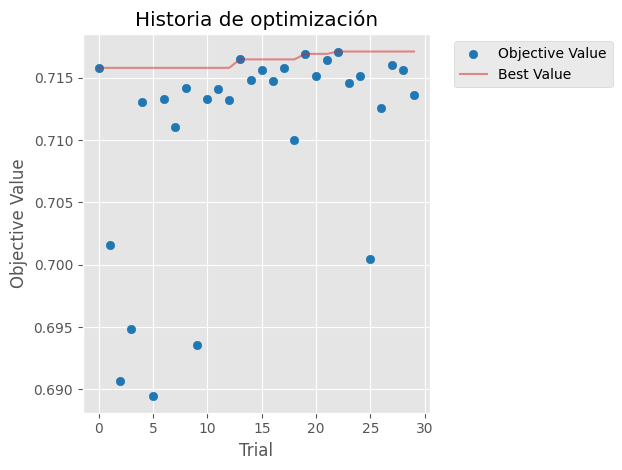

In [59]:
print_results(rf_s3_optuna_results)
save_results(rf_s3_optuna_results, 'rf_s3_optuna_best_params.json', 'Parameters')

### Extreme Gradient Boosting

In [60]:
xgb_model_s3 = XGBClassifier(random_state=42)
xgb_s3_optuna_results = optuna_fine_tune_classification_model(
    X_train=X_train_s3,
    y_train=y_train_s3,
    model=xgb_model_s3,
    param_suggest_dict=param_suggest_dict_xgb,
    X_test=X_test_s3,
    y_test=y_test_s3,
    n_trials=30,
    cv=3,
    scoring='roc_auc',
    direction='maximize',
    timeout=None,
    resampling_strategy='smoteenn',
    random_state=42
)

[I 2025-04-28 16:12:44,727] A new study created in memory with name: no-name-d6f0a41a-a020-4df1-9313-626f5de83ba0


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-04-28 16:12:52,690] Trial 0 finished with value: 0.7061091508500178 and parameters: {'max_depth': 5, 'learning_rate': 0.2536999076681772, 'n_estimators': 233, 'min_child_weight': 6, 'subsample': 0.5780093202212182, 'colsample_bytree': 0.5779972601681014, 'gamma': 0.2904180608409973}. Best is trial 0 with value: 0.7061091508500178.
[I 2025-04-28 16:13:01,921] Trial 1 finished with value: 0.7110559411049149 and parameters: {'max_depth': 9, 'learning_rate': 0.07725378389307355, 'n_estimators': 227, 'min_child_weight': 1, 'subsample': 0.9849549260809971, 'colsample_bytree': 0.9162213204002109, 'gamma': 1.0616955533913808}. Best is trial 1 with value: 0.7110559411049149.
[I 2025-04-28 16:13:08,717] Trial 2 finished with value: 0.702285042491351 and parameters: {'max_depth': 4, 'learning_rate': 0.018659959624904916, 'n_estimators': 126, 'min_child_weight': 6, 'subsample': 0.7159725093210578, 'colsample_bytree': 0.645614570099021, 'gamma': 3.0592644736118975}. Best is trial 1 with val

Mejor puntuación (ROC AUC): 0.7140

Mejores parámetros encontrados:
- max_depth: 8
- learning_rate: 0.06641172652148446
- n_estimators: 161
- min_child_weight: 2
- subsample: 0.9346255406660264
- colsample_bytree: 0.8055720048917332
- gamma: 1.7148106400383822

Métricas en el conjunto de prueba:
- accuracy: 0.6274
- precision: 0.4729
- recall: 0.7528
- f1: 0.5809
- roc_auc: 0.7135

Importancia de los parámetros:
- max_depth: 0.3504
- n_estimators: 0.2160
- subsample: 0.1115
- gamma: 0.1068
- min_child_weight: 0.1001
- learning_rate: 0.0774
- colsample_bytree: 0.0379


<ipython-input-30-6e4859f440e2>:18: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(results['study'])


<Figure size 1000x600 with 0 Axes>

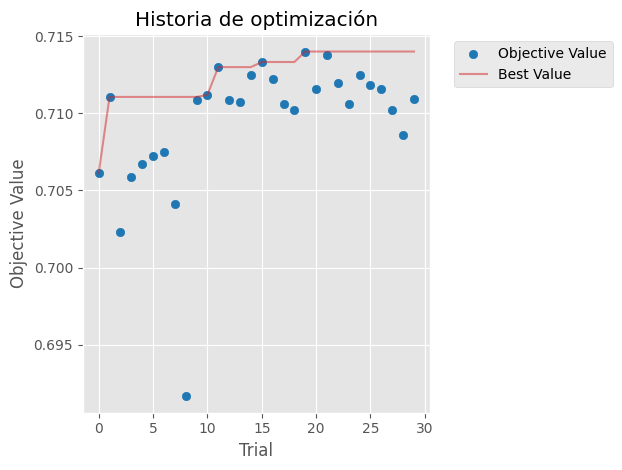

In [61]:
print_results(xgb_s3_optuna_results)
save_results(xgb_s3_optuna_results, 'xgb_s3_optuna_best_params.json', 'Parameters')

### K Nearest Neighbors

In [ ]:
knn_model_s3 = KNeighborsClassifier()
knn_s3_optuna_results = optuna_fine_tune_classification_model(
    X_train=X_train_s3,
    y_train=y_train_s3,
    model=knn_model_s3,
    param_suggest_dict=param_suggest_dict_knn,
    X_test=X_test_s3,
    y_test=y_test_s3,
    n_trials=30,
    cv=3,
    scoring='roc_auc',
    direction='maximize',
    timeout=None,
    resampling_strategy='smoteenn',
    random_state=42
)

[I 2025-04-28 16:16:57,830] A new study created in memory with name: no-name-98d6ad4d-f533-4231-a54e-a680834dbaf2


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-04-28 16:17:04,345] Trial 0 finished with value: 0.6667764952907644 and parameters: {'n_neighbors': 12, 'weights': 'uniform', 'metric': 'euclidean', 'algorithm': 'auto'}. Best is trial 0 with value: 0.6667764952907644.
Error en trial 1: 
All the 3 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/imblearn/pipe

## Escenario 4

In [ ]:
# Separate features and target
X4 = df[projectsColumns + contractColumns + buyerColumns + supplierColumns + buyerIndicators + terridataColumns]
y4 = df['haveCostDeviation(G7)']

# %%
# select categorical columns
categoricalColumns = X4.select_dtypes(include=['object']).columns
# select numerical columns
numericColumns = X4.select_dtypes(include=['int64', 'float64']).columns

# %%
# Split data into training and testing sets
X_train_s4, X_test_s4, y_train_s4, y_test_s4 = train_test_split(X4, y4, test_size=0.3, random_state=42, stratify=y4)

### Logistic Regression

In [64]:
lr_model_s4 = LogisticRegression(max_iter=10000, solver='liblinear', random_state=42)
lr_s4_optuna_results = optuna_fine_tune_classification_model(
    X_train=X_train_s4,
    y_train=y_train_s4,
    model=lr_model_s4,
    param_suggest_dict=param_suggest_dict_lr,
    X_test=X_test_s4,
    y_test=y_test_s4,
    n_trials=30,
    cv=3,
    scoring='roc_auc',
    direction='maximize',
    timeout=None,
    resampling_strategy='smoteenn',
    random_state=42
)

[I 2025-04-28 17:07:08,399] A new study created in memory with name: no-name-2a5f0dd8-9e41-4ad8-a84a-0590ed2bd87a


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-04-28 17:07:22,060] Trial 0 finished with value: 0.6966328701416887 and parameters: {'penalty': 'l2', 'C': 71.77141927992021}. Best is trial 0 with value: 0.6966328701416887.
[I 2025-04-28 17:07:28,699] Trial 1 finished with value: 0.5 and parameters: {'penalty': 'l1', 'C': 0.0017699302940633358}. Best is trial 0 with value: 0.6966328701416887.
[I 2025-04-28 17:07:33,687] Trial 2 finished with value: 0.7021730141857159 and parameters: {'penalty': 'l2', 'C': 6.4405075539937195}. Best is trial 2 with value: 0.7021730141857159.
[I 2025-04-28 17:07:41,802] Trial 3 finished with value: 0.6926167423488233 and parameters: {'penalty': 'l1', 'C': 5744.851636320435}. Best is trial 2 with value: 0.7021730141857159.
[I 2025-04-28 17:07:47,216] Trial 4 finished with value: 0.6677675588523332 and parameters: {'penalty': 'l1', 'C': 0.002848391870910803}. Best is trial 2 with value: 0.7021730141857159.
[I 2025-04-28 17:07:52,038] Trial 5 finished with value: 0.7060986525731296 and parameters: 

Mejor puntuación (ROC AUC): 0.7095

Mejores parámetros encontrados:
- penalty: l2
- C: 0.21646957606393527

Métricas en el conjunto de prueba:
- accuracy: 0.5660
- precision: 0.4296
- recall: 0.8097
- f1: 0.5614
- roc_auc: 0.6980

Importancia de los parámetros:
- C: 0.6922
- penalty: 0.3078


<ipython-input-30-6e4859f440e2>:18: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(results['study'])


<Figure size 1000x600 with 0 Axes>

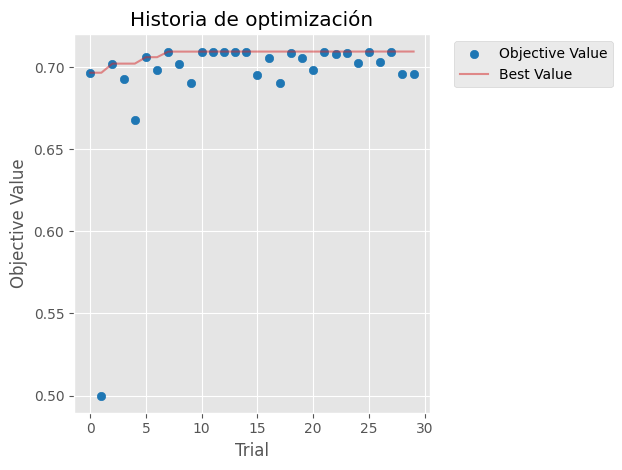

In [65]:
print_results(lr_s4_optuna_results)
save_results(lr_s4_optuna_results, 'lr_s4_optuna_best_params.json', 'Parameters')

### Random Forest

In [66]:
rf_model_s4 = RandomForestClassifier(random_state=42)
rf_s4_optuna_results = optuna_fine_tune_classification_model(
    X_train=X_train_s4,
    y_train=y_train_s4,
    model=rf_model_s4,
    param_suggest_dict=param_suggest_dict_rf,
    X_test=X_test_s4,
    y_test=y_test_s4,
    n_trials=30,
    cv=3,
    scoring='roc_auc',
    direction='maximize',
    timeout=None,
    resampling_strategy='smoteenn',
    random_state=42
)

[I 2025-04-28 17:10:20,804] A new study created in memory with name: no-name-4482d8ed-41f0-4590-9d92-6a72471a9e92


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-04-28 17:10:36,553] Trial 0 finished with value: 0.7255796242798912 and parameters: {'max_depth': 22, 'n_estimators': 478, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features_type': 'auto', 'max_features': 'log2', 'bootstrap': False}. Best is trial 0 with value: 0.7255796242798912.
[I 2025-04-28 17:11:01,465] Trial 1 finished with value: 0.7169266085318998 and parameters: {'max_depth': 5, 'n_estimators': 487, 'min_samples_split': 17, 'min_samples_leaf': 3, 'max_features_type': 'float', 'max_features_float': 0.3433937943676302, 'bootstrap': True}. Best is trial 0 with value: 0.7255796242798912.
[I 2025-04-28 17:12:09,202] Trial 2 finished with value: 0.71041935555261 and parameters: {'max_depth': 18, 'n_estimators': 325, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features_type': 'float', 'max_features_float': 0.728140769114411, 'bootstrap': False}. Best is trial 0 with value: 0.7255796242798912.
[I 2025-04-28 17:12:27,093] Trial 3 finished with value: 0.717250

Mejor puntuación (ROC AUC): 0.7265

Mejores parámetros encontrados:
- max_depth: 32
- n_estimators: 145
- min_samples_split: 6
- min_samples_leaf: 5
- max_features_type: auto
- max_features: log2
- bootstrap: False

Métricas en el conjunto de prueba:
- accuracy: 0.6184
- precision: 0.4673
- recall: 0.8028
- f1: 0.5907
- roc_auc: 0.7302

Importancia de los parámetros:
- max_features_type: 0.6999
- bootstrap: 0.1031
- n_estimators: 0.1026
- min_samples_split: 0.0629
- min_samples_leaf: 0.0188
- max_depth: 0.0127


<ipython-input-30-6e4859f440e2>:18: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(results['study'])


<Figure size 1000x600 with 0 Axes>

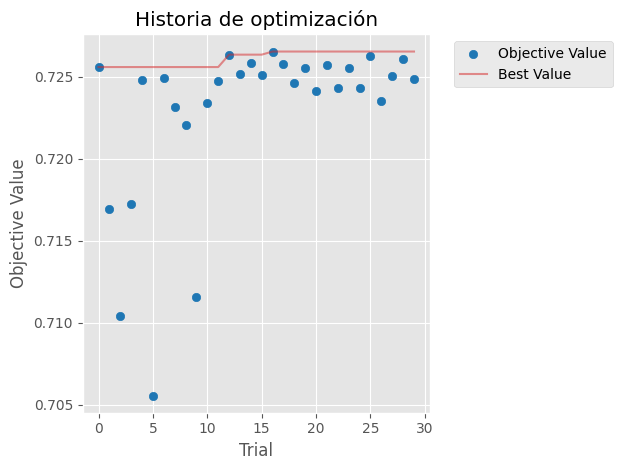

In [67]:
print_results(rf_s4_optuna_results)
save_results(rf_s4_optuna_results, 'rf_s4_optuna_best_params.json', 'Parameters')

### Extreme Gradient Boosting

In [68]:
xgb_model_s4 = XGBClassifier(random_state=42)
xgb_s4_optuna_results = optuna_fine_tune_classification_model(
    X_train=X_train_s4,
    y_train=y_train_s4,
    model=xgb_model_s4,
    param_suggest_dict=param_suggest_dict_xgb,
    X_test=X_test_s4,
    y_test=y_test_s4,
    n_trials=30,
    cv=3,
    scoring='roc_auc',
    direction='maximize',
    timeout=None,
    resampling_strategy='smoteenn',
    random_state=42
)

[I 2025-04-28 17:18:38,569] A new study created in memory with name: no-name-346fd85b-ad34-49ec-9493-71266d6fa451


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-04-28 17:18:44,445] Trial 0 finished with value: 0.714020751246324 and parameters: {'max_depth': 5, 'learning_rate': 0.2536999076681772, 'n_estimators': 233, 'min_child_weight': 6, 'subsample': 0.5780093202212182, 'colsample_bytree': 0.5779972601681014, 'gamma': 0.2904180608409973}. Best is trial 0 with value: 0.714020751246324.
[I 2025-04-28 17:18:54,233] Trial 1 finished with value: 0.7232083109640272 and parameters: {'max_depth': 9, 'learning_rate': 0.07725378389307355, 'n_estimators': 227, 'min_child_weight': 1, 'subsample': 0.9849549260809971, 'colsample_bytree': 0.9162213204002109, 'gamma': 1.0616955533913808}. Best is trial 1 with value: 0.7232083109640272.
[I 2025-04-28 17:18:59,902] Trial 2 finished with value: 0.7177778659173466 and parameters: {'max_depth': 4, 'learning_rate': 0.018659959624904916, 'n_estimators': 126, 'min_child_weight': 6, 'subsample': 0.7159725093210578, 'colsample_bytree': 0.645614570099021, 'gamma': 3.0592644736118975}. Best is trial 1 with valu

Mejor puntuación (ROC AUC): 0.7261

Mejores parámetros encontrados:
- max_depth: 8
- learning_rate: 0.015646775363714505
- n_estimators: 275
- min_child_weight: 1
- subsample: 0.8454910187781736
- colsample_bytree: 0.5058999946626109
- gamma: 3.1442493399373035

Métricas en el conjunto de prueba:
- accuracy: 0.6494
- precision: 0.4927
- recall: 0.7486
- f1: 0.5943
- roc_auc: 0.7303

Importancia de los parámetros:
- n_estimators: 0.4750
- subsample: 0.2621
- max_depth: 0.1283
- gamma: 0.0514
- learning_rate: 0.0311
- colsample_bytree: 0.0311
- min_child_weight: 0.0211


<ipython-input-30-6e4859f440e2>:18: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(results['study'])


<Figure size 1000x600 with 0 Axes>

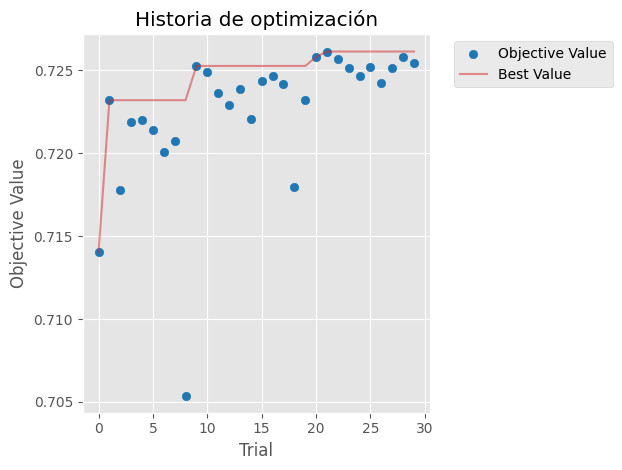

In [69]:
print_results(xgb_s4_optuna_results)
save_results(xgb_s4_optuna_results, 'xgb_s4_optuna_best_params.json', 'Parameters')

### K Nearest Neighbors

In [70]:
knn_model_s4 = KNeighborsClassifier()
knn_s4_optuna_results = optuna_fine_tune_classification_model(
    X_train=X_train_s4,
    y_train=y_train_s4,
    model=knn_model_s4,
    param_suggest_dict=param_suggest_dict_knn,
    X_test=X_test_s4,
    y_test=y_test_s4,
    n_trials=30,
    cv=3,
    scoring='roc_auc',
    direction='maximize',
    timeout=None,
    resampling_strategy='smoteenn',
    random_state=42
)

[I 2025-04-28 17:23:01,309] A new study created in memory with name: no-name-454eb966-eaf8-4805-bbf7-bbd06c325f8b


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-04-28 17:23:08,344] Trial 0 finished with value: 0.68492233877571 and parameters: {'n_neighbors': 12, 'weights': 'uniform', 'metric': 'euclidean', 'algorithm': 'auto'}. Best is trial 0 with value: 0.68492233877571.


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
2 fits failed out of a total of 3.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/imblearn/pipeline.py", line 526, in fit
    self._final_estimator.fit(Xt, yt, **las

[W 2025-04-28 17:23:13,706] Trial 1 failed with parameters: {'n_neighbors': 30, 'weights': 'uniform', 'metric': 'chebyshev', 'algorithm': 'kd_tree', 'leaf_size': 36} because of the following error: The value nan is not acceptable.
[W 2025-04-28 17:23:13,708] Trial 1 failed with value np.float64(nan).


...

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
2 fits failed out of a total of 3.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/imblearn/pipeline.py", line 526, in fit
    self._final_estimator.fit(Xt, yt, **las

[W 2025-04-28 17:26:38,371] Trial 28 failed with parameters: {'n_neighbors': 20, 'weights': 'distance', 'metric': 'chebyshev', 'algorithm': 'ball_tree', 'leaf_size': 36} because of the following error: The value nan is not acceptable.
[W 2025-04-28 17:26:38,374] Trial 28 failed with value np.float64(nan).


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
2 fits failed out of a total of 3.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/imblearn/pipeline.py", line 526, in fit
    self._final_estimator.fit(Xt, yt, **las

[W 2025-04-28 17:26:43,965] Trial 29 failed with parameters: {'n_neighbors': 6, 'weights': 'distance', 'metric': 'chebyshev', 'algorithm': 'ball_tree', 'leaf_size': 43} because of the following error: The value nan is not acceptable.
[W 2025-04-28 17:26:43,971] Trial 29 failed with value np.float64(nan).


/usr/local/lib/python3.11/dist-packages/sklearn/neighbors/_base.py:598: UserWarning: cannot use tree with sparse input: using brute force
  warnings.warn("cannot use tree with sparse input: using brute force")


Mejor puntuación (ROC AUC): 0.7018

Mejores parámetros encontrados:
- n_neighbors: 15
- weights: uniform
- metric: manhattan
- algorithm: ball_tree
- leaf_size: 54

Métricas en el conjunto de prueba:
- accuracy: 0.6446
- precision: 0.4863
- recall: 0.6403
- f1: 0.5528
- roc_auc: 0.7089

Importancia de los parámetros:
- n_neighbors: 0.4876
- metric: 0.2506
- algorithm: 0.1951
- weights: 0.0667


<ipython-input-30-6e4859f440e2>:18: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(results['study'])


<Figure size 1000x600 with 0 Axes>

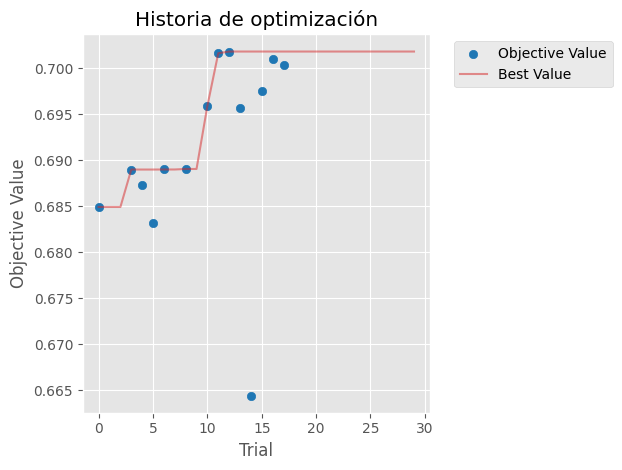

In [71]:
print_results(knn_s4_optuna_results)
save_results(knn_s4_optuna_results, 'knn_s4_optuna_best_params.json', 'Parameters')